In [ ]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def build_regimes(csv_path="machine_operating_data.csv", seed=180, verbose=False):
    """CNC machine operating telemetry — UNLABELLED readings to be clustered into
    operating regimes (e.g. idle / roughing / finishing / heavy-cut). Built with a few
    genuine latent regimes so k-means has real structure to recover, plus features on
    very different scales (scaling lesson) for the U18 clustering lab.

    Features:
      spindle_rpm        spindle speed (rev/min)
      feed_rate_mmpm     feed rate (mm/min)
      cut_depth_mm       depth of cut (mm)
      power_kw           spindle power (kW)
       coolant_lpm        coolant flow (L/min)
      tool_temp_c        tool temperature (deg C)
    No label column (the 'regime' is what clustering should discover).
    """
    rng = np.random.default_rng(seed)
    # latent regimes: (rpm, feed, depth, power, vib, coolant, temp), weight
    regimes = [
        ("idle",      (700,   0,    0.0,  1.5,  0.6, 2,   28), 0.20),
        ("roughing",  (1500,  400,  3.5,  18,   5.5, 25,  62), 0.30),
        ("finishing", (3000,  180,  0.6,  9,    2.2, 18,  48), 0.30),
        ("heavy_cut", (1100,  600,  6.0,  26,   8.5, 30,  78), 0.20),
    ]
    N = 1500
    rows = []
    for name, mu, w in regimes:
        n = int(N * w)
        spread = np.array([120, 50, 0.4, 2.0, 0.7, 3, 5])
        block = rng.normal(mu, spread, size=(n, 7))
        rows.append(block)
    X = np.vstack(rows)
    X[:, :] = np.clip(X, 0, None)
    rng.shuffle(X)

    df = pd.DataFrame(X, columns=[
        "spindle_rpm", "feed_rate_mmpm", "cut_depth_mm", "power_kw",
        "vibration_mm_s", "coolant_lpm", "tool_temp_c"])
    df["spindle_rpm"] = df.spindle_rpm.round(0).astype(int)
    df["feed_rate_mmpm"] = df.feed_rate_mmpm.round(0).astype(int)
    for c in ["cut_depth_mm", "power_kw", "vibration_mm_s", "tool_temp_c"]:
        df[c] = df[c].round(2)
    df["coolant_lpm"] = df.coolant_lpm.round(1)
    df.to_csv(csv_path, index=False)
    if verbose:
        print("regimes:", df.shape)
        print("feature ranges (max-min):")
        print((df.max() - df.min()).round(1).to_string())
        print("(built from 4 latent regimes; no label column kept)")
    return df

if not os.path.exists('machine_operating_data.csv'):
    build_regimes(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')
    # Removed redundant imports here as they are now at the top
sns.set_theme(style='whitegrid')
df = pd.read_csv('machine_operating_data.csv')
print('readings:', df.shape)
print('feature ranges (max-min) — note how different they are:')
print((df.max() - df.min()).round(1).to_string())
df.head(3)

Found the provided dataset file.
readings: (1500, 7)
feature ranges (max-min) — note how different they are:
spindle_rpm       2924.0
feed_rate_mmpm     781.0
cut_depth_mm         7.1
power_kw            31.4
vibration_mm_s      10.2
coolant_lpm         39.5
tool_temp_c         75.6


,spindle_rpm,feed_rate_mmpm,cut_depth_mm,power_kw,vibration_mm_s,coolant_lpm,tool_temp_c
0,2860,202,0.49,7.78,3.06,20.3,42.31
1,1373,428,3.60,20.04,6.28,29.1,61.35
2,3031,237,0.36,12.23,3.17,14.1,47.21


In [ ]:

# -----------------------------------------------------------
# 🔹 1A. WHY: spindle_rpm spans ~3000, cut_depth spans ~7
# -----------------------------------------------------------
from sklearn.preprocessing import StandardScaler
X = df.values
Xs = StandardScaler().fit_transform(X)
print('raw    feature stds:', np.round(X.std(axis=0), 1))
print('scaled feature stds:', np.round(Xs.std(axis=0), 1))
print('After scaling every feature has std ~1, so each gets an equal vote in the distance.')


raw    feature stds: [896.  208.6   2.2   8.6   2.9  10.   17.4]
scaled feature stds: [1. 1. 1. 1. 1. 1. 1.]
After scaling every feature has std ~1, so each gets an equal vote in the distance.


In [ ]:
from sklearn.cluster import KMeans
import numpy as np

# KMeans on raw data
kmeans_raw = KMeans(n_clusters=4, n_init=10, random_state=0)
labels_raw = kmeans_raw.fit_predict(X)

print("Cluster sizes (Raw Data):")
print(np.bincount(labels_raw))

# KMeans on scaled data
kmeans_scaled = KMeans(n_clusters=4, n_init=10, random_state=0)
labels_scaled = kmeans_scaled.fit_predict(Xs)

print("\nCluster sizes (Scaled Data):")
print(np.bincount(labels_scaled))

Cluster sizes (Raw Data):
[444 450 300 306]

Cluster sizes (Scaled Data):
[450 300 450 300]


inertia (within-cluster SSE): 549.9
cluster sizes: [450 300 450 300]
n_init=10 runs k-means 10 times from different starts and keeps the lowest-inertia result.


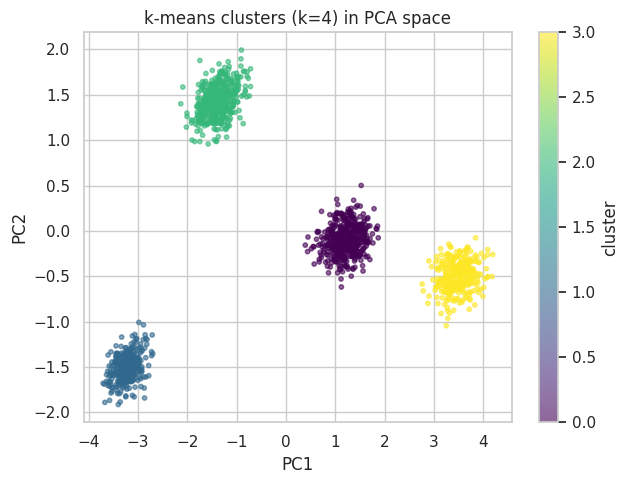

In [ ]:
# -----------------------------------------------------------
# 🔹 2A. FIT k-MEANS (k=4) ON SCALED DATA
# -----------------------------------------------------------
from sklearn.cluster import KMeans
km = KMeans(n_clusters=4, n_init=10, random_state=0).fit(Xs)
print('inertia (within-cluster SSE):', round(km.inertia_, 1))
print('cluster sizes:', np.bincount(km.labels_))
print('n_init=10 runs k-means 10 times from different starts and keeps the lowest-inertia result.')


# -----------------------------------------------------------
# 🔹 2B. VISUALISE CLUSTERS IN 2-D (via PCA)
# -----------------------------------------------------------
from sklearn.decomposition import PCA
P2 = PCA(n_components=2).fit_transform(Xs)
fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(P2[:, 0], P2[:, 1], c=km.labels_, cmap='viridis', s=10, alpha=0.6)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('k-means clusters (k=4) in PCA space')
plt.colorbar(sc, label='cluster'); plt.tight_layout(); plt.show()

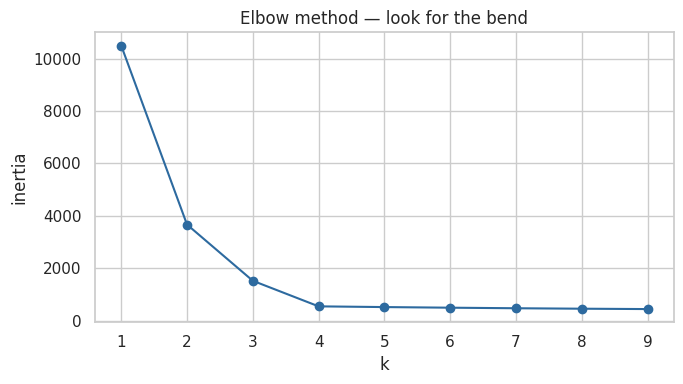

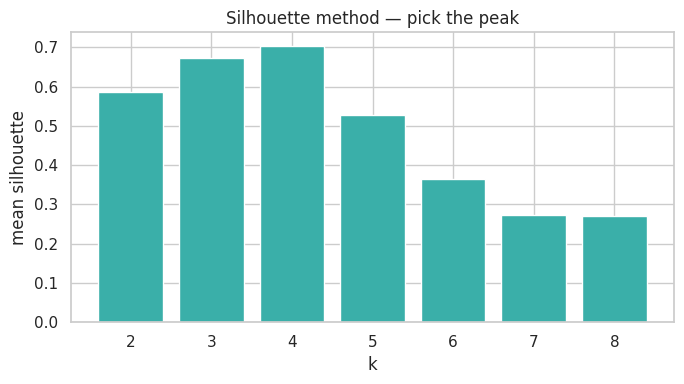

highest silhouette at k = 4


In [ ]:
# -----------------------------------------------------------
# 🔹 3A. THE ELBOW METHOD (inertia vs k)
# -----------------------------------------------------------
ks = range(1, 10); inertias = []
for k in ks:
    inertias.append(KMeans(n_clusters=k, n_init=10, random_state=0).fit(Xs).inertia_)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(ks), inertias, 'o-', color='#2D6A9F')
ax.set_xlabel('k'); ax.set_ylabel('inertia'); ax.set_title('Elbow method — look for the bend')
plt.tight_layout(); plt.show()


# -----------------------------------------------------------
# 🔹 3B. THE SILHOUETTE METHOD (higher = better separated)
# -----------------------------------------------------------
from sklearn.metrics import silhouette_score
ks2 = range(2, 9); sils = []
for k in ks2:
    labels = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xs)
    sils.append(silhouette_score(Xs, labels))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([str(k) for k in ks2], sils, color='#3AAFA9')
ax.set_xlabel('k'); ax.set_ylabel('mean silhouette'); ax.set_title('Silhouette method — pick the peak')
plt.tight_layout(); plt.show()
best_k = list(ks2)[int(np.argmax(sils))]
print('highest silhouette at k =', best_k)


In [ ]:
print("Best k from silhouette score:", best_k)

Best k from silhouette score: 4


In [ ]:

# -----------------------------------------------------------
# 🔹 4A. INTERNAL METRICS AT THE CHOSEN k
# -----------------------------------------------------------
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
labels = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit_predict(Xs)
print(f'k = {best_k}')
print('Silhouette       (higher better):', round(silhouette_score(Xs, labels), 3))
print('Davies-Bouldin   (lower  better):', round(davies_bouldin_score(Xs, labels), 3))
print('Calinski-Harabasz(higher better):', round(calinski_harabasz_score(Xs, labels), 1))


k = 4
Silhouette       (higher better): 0.703
Davies-Bouldin   (lower  better): 0.439
Calinski-Harabasz(higher better): 9022.9


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# 1. Metrics for best_k vs best_k + 1
for k in [best_k, best_k + 1]:
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    labels = km.fit_predict(Xs)

    sil = silhouette_score(Xs, labels)
    ch = calinski_harabasz_score(Xs, labels)
    db = davies_bouldin_score(Xs, labels)

    print(f"\nk = {k}")
    print(f"Silhouette Score        : {sil:.4f}")
    print(f"Calinski-Harabasz Score : {ch:.2f}")
    print(f"Davies-Bouldin Score    : {db:.4f}")



k = 4
Silhouette Score        : 0.7032
Calinski-Harabasz Score : 9022.92
Davies-Bouldin Score    : 0.4385

k = 5
Silhouette Score        : 0.5269
Calinski-Harabasz Score : 7138.76
Davies-Bouldin Score    : 1.1814


         spindle_rpm  feed_rate_mmpm  cut_depth_mm  power_kw  vibration_mm_s  coolant_lpm  tool_temp_c
cluster                                                                                               
0             1496.2           399.6           3.5      18.0             5.5         25.0         61.9
1              699.1            19.7           0.2       1.8             0.6          2.3         28.0
2             2993.8           177.7           0.6       8.9             2.2         18.0         47.9
3             1096.3           600.7           6.0      25.8             8.5         30.1         77.8

Read each row as the typical machine state for that cluster.


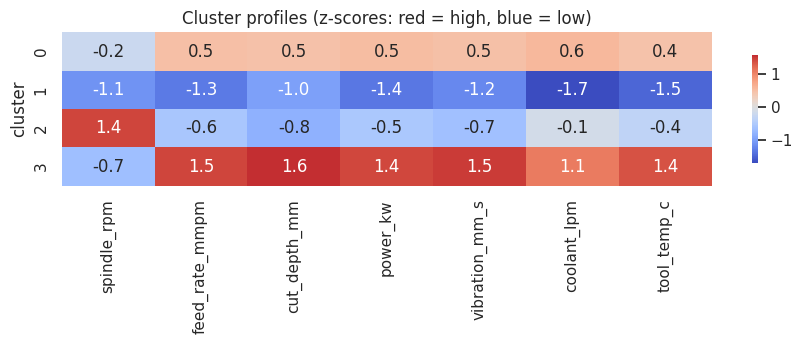

In [ ]:
# -----------------------------------------------------------
# 🔹 5A. CLUSTER PROFILES = MEAN OF EACH FEATURE PER CLUSTER
# -----------------------------------------------------------
df_lab = df.copy()
df_lab['cluster'] = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit_predict(Xs)
profile = df_lab.groupby('cluster').mean().round(1)
print(profile.to_string())
print('\nRead each row as the typical machine state for that cluster.')


# -----------------------------------------------------------
# 🔹 5B. HEATMAP OF PROFILES (standardised for readability)
# -----------------------------------------------------------
prof_z = (profile - df.mean()) / df.std()
fig, ax = plt.subplots(figsize=(9, 3.6))
sns.heatmap(prof_z, annot=True, fmt='.1f', cmap='coolwarm', center=0, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Cluster profiles (z-scores: red = high, blue = low)'); plt.tight_layout(); plt.show()


In [ ]:
cluster_names = {
    0: "Idle / Low Activity",
    1: "Finishing (High RPM, Low Depth)",
    2: "Roughing (High Feed & Depth)",
    3: "Heavy Cut / High Load"
}

print("Cluster → Regime Mapping:")
for k, v in cluster_names.items():
    print(f"Cluster {k}: {v}")

Cluster → Regime Mapping:
Cluster 0: Idle / Low Activity
Cluster 1: Finishing (High RPM, Low Depth)
Cluster 2: Roughing (High Feed & Depth)
Cluster 3: Heavy Cut / High Load


In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

# 1. DBSCAN on Xs; count clusters and noise points
dbscan = DBSCAN(eps=1.0, min_samples=10)
labels = dbscan.fit_predict(Xs)

# number of clusters (excluding noise label -1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# number of noise points
n_noise = np.sum(labels == -1)

print("Number of clusters found:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters found: 4
Number of noise points: 0
